# 02 – SAR (openEO) and Sentinel-2 (DEA / odc-stac) Data Access

Reproduces Sections 3.3.3 and 3.4.2:
- Sentinel-1 GRD gamma0 terrain-corrected backscatter via openEO
- Sentinel-2 surface reflectance (DEA Collection 3) via odc-stac
- Cloud masking
- Annual, seasonal, and dry-season composites (Section 4.2)
- Save outputs as Zarr stores for use in Notebook 03

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from src import config
from src.remote_sensing import (
    connect_openeo,
    fetch_sar_backscatter,
    load_sentinel2_dea,
    mask_clouds_s2,
    compute_sar_composite,
    compute_sar_variability,
    compute_s2_composite,
)
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

## 2.1 Load bounding box from Notebook 01

In [2]:
bbox_path = config.OUTPUT_DIR / 'bbox_lonlat.json'
with open(bbox_path) as f:
    bb = json.load(f)
bbox_lonlat = (bb['minlon'], bb['minlat'], bb['maxlon'], bb['maxlat'])
print(f"AOI: {bbox_lonlat}")

AOI: (118.52630272428725, -20.657588290191065, 118.53580876094986, -20.648470372929953)


## 2.2 Sentinel-1 SAR via openEO

`authenticate_oidc()` will open a browser login on first use.
Register for free at https://dataspace.copernicus.eu if you haven't already.

In [3]:
# con = connect_openeo()
# print("Connected to:", con)

In [4]:
sar_ds = fetch_sar_backscatter(
    bbox_lonlat=bbox_lonlat,
    date_start=config.DATE_START,
    date_end=config.DATE_END,
)
print(sar_ds)
# sar_ds = fetch_sar_backscatter(
#     connection=con,
#     bbox_lonlat=bbox_lonlat,
#     date_start=config.DATE_START,
#     date_end=config.DATE_END,
#     # out_path=config.OUTPUT_DIR / 'sar_raw.nc',
# )
# print(sar_ds)

Found 35 Sentinel-1 RTC scenes
<xarray.Dataset> Size: 864kB
Dimensions:      (y: 56, x: 55, time: 35)
Coordinates:
  * y            (y) float64 448B -2.29e+06 -2.29e+06 ... -2.291e+06 -2.291e+06
  * x            (x) float64 440B -1.393e+06 -1.393e+06 ... -1.392e+06
    spatial_ref  int32 4B 3577
  * time         (time) datetime64[ns] 280B 2024-06-01T21:32:22.781265 ... 20...
Data variables:
    VV           (time, y, x) float32 431kB dask.array<chunksize=(1, 56, 55), meta=np.ndarray>
    VH           (time, y, x) float32 431kB dask.array<chunksize=(1, 56, 55), meta=np.ndarray>


### 2.2.1 SAR temporal composites

In [5]:
# Annual median (one raster per year)
years = range(int(config.DATE_START[:4]), int(config.DATE_END[:4]) + 1)
sar_composites = {}

for yr in years:
    yr_ds = sar_ds.sel(time=str(yr))
    if yr_ds.time.size == 0:
        continue
    sar_composites[f'annual_{yr}'] = compute_sar_composite(yr_ds, period='annual')

# Seasonal composites (pooled across all years)
for season in config.SEASONS:
    sar_composites[season] = compute_sar_composite(sar_ds, period=season)

# Dry-season composite
sar_composites['dryseason'] = compute_sar_composite(sar_ds, period='dryseason')

# Inter-seasonal variability
sar_composites['variability'] = compute_sar_variability(sar_ds)

print("SAR composites computed:", list(sar_composites.keys()))

SAR composites computed: ['annual_2024', 'annual_2025', 'winter', 'spring', 'summer', 'autumn', 'dryseason', 'variability']


In [ ]:
# Save all SAR composites to a single Zarr store
sar_all = xr.concat(
    [v.expand_dims('period') for v in sar_composites.values()],
    dim=xr.DataArray(list(sar_composites.keys()), dims='period'),
)
# sar_all.to_zarr(config.SAR_ZARR, mode='w')
# print(f"SAR composites saved to {config.SAR_ZARR}")
sar_all.to_netcdf(config.SRA_NC)
print(f"SAR composites saved to {config.SRA_NC}")

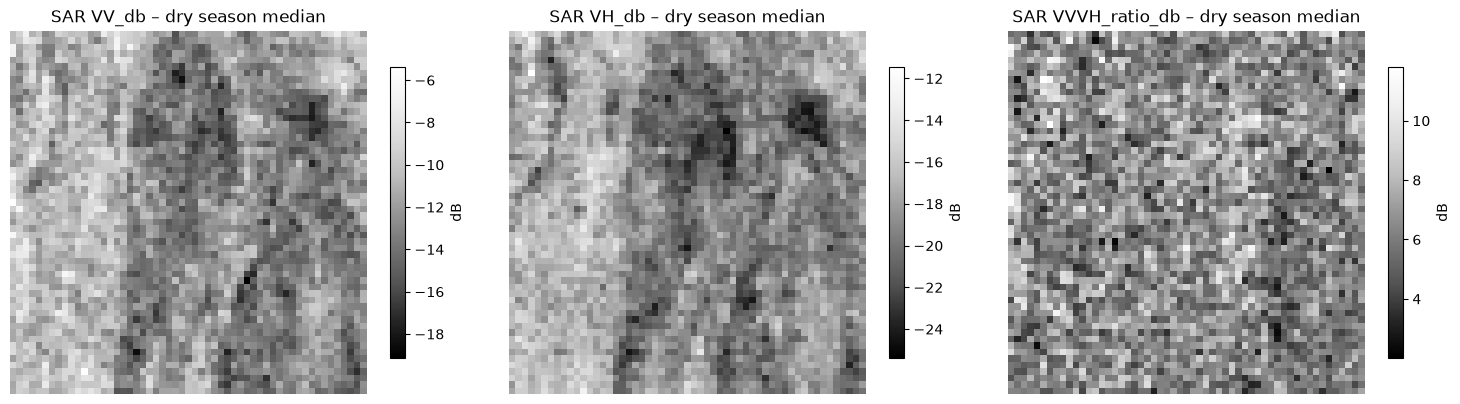

In [7]:
# Quick-look: annual dry-season VV median
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var in zip(axes, ['VV_db', 'VH_db', 'VVVH_ratio_db']):
    arr = sar_composites['dryseason'][var].values
    im = ax.imshow(arr, cmap='Greys_r', origin='upper')
    ax.set_title(f'SAR {var} – dry season median')
    plt.colorbar(im, ax=ax, shrink=0.8, label='dB')
    ax.axis('off')
plt.tight_layout()
plt.savefig(config.OUTPUT_DIR / 'qc_sar_composites.png', dpi=150)
plt.show()

## 2.3 Sentinel-2 via Digital Earth Australia (odc-stac)

Loads DEA Collection 3 analysis-ready surface reflectance for all 10 bands
in Table 1, with s2cloudless cloud masking (Section 3.4.2).

In [8]:
# chunks={"x": 2048, "y": 2048, "time": 5} for large areas;
# leave as None for small test extents.
s2_ds = load_sentinel2_dea(
    bbox_lonlat=bbox_lonlat,
    date_start=config.DATE_START,
    date_end=config.DATE_END,
    chunks=None,
)
print(s2_ds)
print(f"Scenes loaded: {s2_ds.time.size}")

dict_keys(['oa_fmask', 'nbart_red', 'nbart_blue', 'nbart_green', 'nbart_nir_1', 'nbart_nir_2', 'nbart_swir_2', 'nbart_swir_3', 'oa_time_delta', 'oa_solar_zenith', 'nbart_red_edge_1', 'nbart_red_edge_2', 'nbart_red_edge_3', 'oa_exiting_angle', 'oa_solar_azimuth', 'oa_incident_angle', 'oa_relative_slope', 'oa_satellite_view', 'oa_nbart_contiguity', 'oa_relative_azimuth', 'oa_s2cloudless_mask', 'oa_s2cloudless_prob', 'oa_azimuthal_exiting', 'oa_satellite_azimuth', 'nbart_coastal_aerosol', 'oa_azimuthal_incident', 'oa_combined_terrain_shadow', 'checksum:sha1', 'thumbnail:nbart', 'metadata:processor'])
<xarray.Dataset> Size: 5MB
Dimensions:              (y: 56, x: 55, time: 56)
Coordinates:
  * y                    (y) float64 448B -2.29e+06 -2.29e+06 ... -2.291e+06
  * x                    (x) float64 440B -1.393e+06 -1.393e+06 ... -1.392e+06
    spatial_ref          int32 4B 3577
  * time                 (time) datetime64[ns] 448B 2024-06-04T02:23:23.47083...
Data variables:
    nbart_blu

### 2.3.1 Cloud masking

In [9]:
s2_masked = mask_clouds_s2(s2_ds)
print("Cloud masking complete")

Cloud masking complete


### 2.3.2 Geometric median composites

In [10]:
s2_composites = {}

for yr in years:
    yr_ds = s2_masked.sel(time=str(yr))
    if yr_ds.time.size == 0:
        continue
    s2_composites[f'annual_{yr}'] = compute_s2_composite(yr_ds, period='annual')

for season in config.SEASONS:
    s2_composites[season] = compute_s2_composite(s2_masked, period=season)

s2_composites['dryseason'] = compute_s2_composite(s2_masked, period='dryseason')

print("Sentinel-2 geomedian composites computed:", list(s2_composites.keys()))

Sentinel-2 geomedian composites computed: ['annual_2024', 'annual_2025', 'winter', 'spring', 'summer', 'autumn', 'dryseason']


In [14]:
# Save to Zarr
s2_all = xr.concat(
    [v.expand_dims('period') for v in s2_composites.values()],
    dim=xr.DataArray(list(s2_composites.keys()), dims='period'),
)
# s2_all.to_zarr(config.S2_ZARR, mode='w')
# print(f"Sentinel-2 composites saved to {config.S2_ZARR}")
s2_all.to_netcdf(config.S2_NC)
print(f"Sentinel-2 composites saved to {config.S2_NC}")

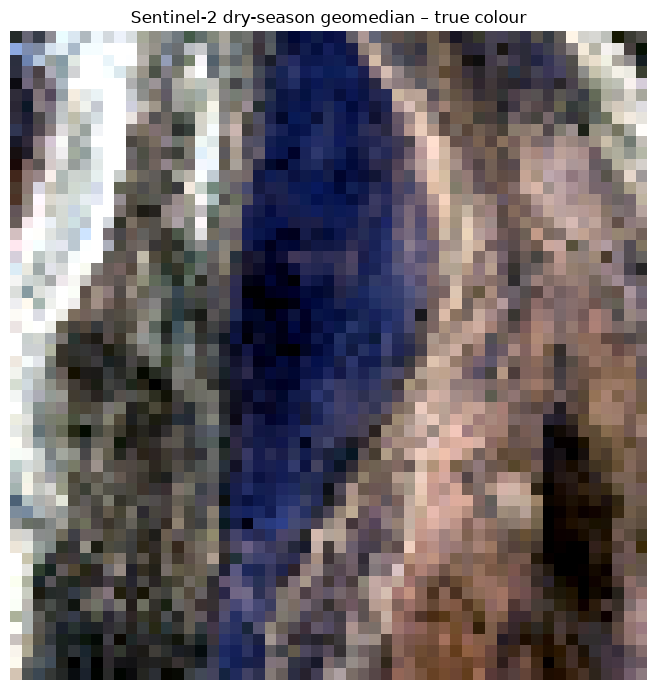

In [12]:
# Quick-look: dry season true-colour and SWIR
ds_dry = s2_composites['dryseason']
red = ds_dry['nbart_red'].values
green = ds_dry['nbart_green'].values
blue = ds_dry['nbart_blue'].values

def normalise(arr, pct=(2, 98)):
    lo, hi = np.nanpercentile(arr, pct)
    return np.clip((arr - lo) / (hi - lo), 0, 1)

rgb = np.stack([normalise(red), normalise(green), normalise(blue)], axis=-1)
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(rgb, origin='upper')
ax.set_title('Sentinel-2 dry-season geomedian – true colour')
ax.axis('off')
plt.tight_layout()
plt.savefig(config.OUTPUT_DIR / 'qc_s2_truecolour_dryseason.png', dpi=150)
plt.show()